In [1]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 100 
IMAGE_SIZE = 28 * 28 
BATCH_SIZE = 128
LEARNING_RATE = 0.0002
BETA1 = 0.5 
NUM_EPOCHS = 50

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, image_size):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, image_size),
            nn.Tanh()  # Sortie entre -1 et 1
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, image_size):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(image_size, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # Probabilité entre 0 et 1
        )

    def forward(self, img):
        """img: image aplatie de dimension image_size"""
        return self.model(img)

In [4]:
def load_data():
    """Charge le dataset MNIST"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    return dataloader

In [24]:
generator = Generator(LATENT_DIM, IMAGE_SIZE).to(DEVICE)
discriminator = Discriminator(IMAGE_SIZE).to(DEVICE)

criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer_G = Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizer_D = Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

dataloader = load_data()

# Labels
real_label = 1.0
fake_label = 0.0

G_losses = []
D_losses = []

In [6]:
def generate_and_plot(generator, noise, num_images=16):
    
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(noise).cpu().view(-1, 1, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(num_images):
        ax = axes[i // 4, i % 4]
        ax.imshow(fake_imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()

In [36]:
def train_gan(discriminator_trainable=True):
    print(f"Training GAN... (discriminator_trainable={discriminator_trainable})")
    num_images = 16
    noise = torch.randn(num_images, LATENT_DIM, device=DEVICE)
    
    for epoch in range(NUM_EPOCHS):
        for i,(imgs,_) in enumerate(dataloader):
            real_imgs = imgs.view(-1, IMAGE_SIZE).to(DEVICE)
            batch_size = real_imgs.size(0)
            
            # ==================== Train Discriminator ====================
            if discriminator_trainable:
                discriminator.zero_grad()
                
                # Real images
                labels_real = torch.full((batch_size, 1), real_label, device=DEVICE)
                output_real = discriminator(real_imgs)
                loss_real = criterion(output_real, labels_real)

                # Fake images
                noise = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
                fake_imgs = generator(noise)
                labels_fake = torch.full((batch_size, 1), fake_label, device=DEVICE)
                output_fake = discriminator(fake_imgs.detach())
                loss_fake = criterion(output_fake, labels_fake)

                # Update discriminator
                loss_D = loss_real + loss_fake
                loss_D.backward()
                optimizer_D.step()
            else:
                # Skip discriminator training but still generate fake images
                noise = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
                fake_imgs = generator(noise)
                loss_D = torch.tensor(0.0)  # Placeholder for logging

            # ==================== Train Generator ====================
            generator.zero_grad()
            
            labels_gen = torch.full((batch_size, 1), real_label, device=DEVICE)
            output_gen = discriminator(fake_imgs)
            loss_G = criterion(output_gen, labels_gen)
            loss_G.backward()
            optimizer_G.step()
            
            # Print progress
            if i % 100 == 0:
                print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch {i}/{len(dataloader)} | \
Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")
                torch.save(generator.state_dict(), "generator.pth")
                
        if (epoch + 1) % 10 == 0:
            generate_and_plot(generator, noise)
            torch.save(generator.state_dict(), "generator.pth")
            torch.save(discriminator.state_dict(), "discriminator.pth")

Training GAN...
Epoch [1/50] Batch 0/469                         Loss D: 1.2889, Loss G: 0.8171
Epoch [1/50] Batch 100/469                         Loss D: 1.2969, Loss G: 0.8177
Epoch [1/50] Batch 200/469                         Loss D: 1.2860, Loss G: 0.8618
Epoch [1/50] Batch 300/469                         Loss D: 1.3653, Loss G: 0.9846
Epoch [1/50] Batch 400/469                         Loss D: 1.2969, Loss G: 0.8860
Epoch [2/50] Batch 0/469                         Loss D: 1.3562, Loss G: 0.8223
Epoch [2/50] Batch 100/469                         Loss D: 1.3570, Loss G: 0.9191
Epoch [2/50] Batch 200/469                         Loss D: 1.3334, Loss G: 0.8741
Epoch [2/50] Batch 300/469                         Loss D: 1.3868, Loss G: 0.9574
Epoch [2/50] Batch 400/469                         Loss D: 1.3388, Loss G: 0.8197
Epoch [3/50] Batch 0/469                         Loss D: 1.2763, Loss G: 0.7962
Epoch [3/50] Batch 100/469                         Loss D: 1.3278, Loss G: 0.9678
Epoch 

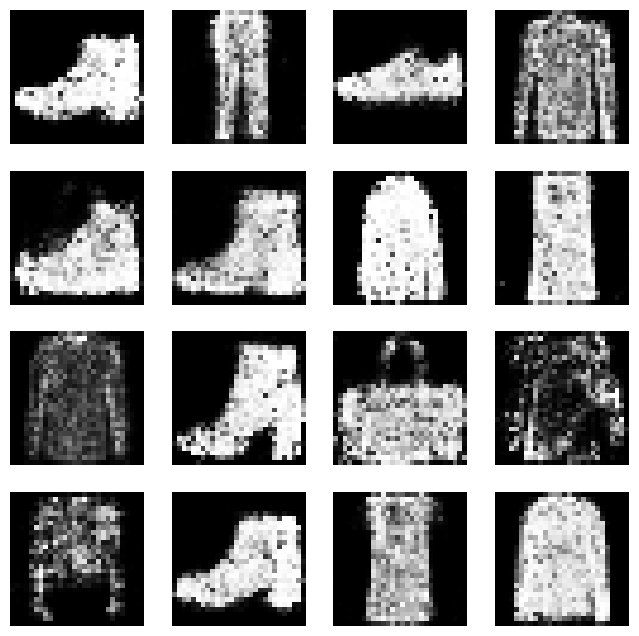

Epoch [11/50] Batch 0/469                         Loss D: 1.3253, Loss G: 0.7212
Epoch [11/50] Batch 100/469                         Loss D: 1.3356, Loss G: 0.8045
Epoch [11/50] Batch 200/469                         Loss D: 1.3249, Loss G: 0.8025
Epoch [11/50] Batch 300/469                         Loss D: 1.3277, Loss G: 0.8980
Epoch [11/50] Batch 400/469                         Loss D: 1.3392, Loss G: 0.7707
Epoch [12/50] Batch 0/469                         Loss D: 1.2785, Loss G: 0.8064
Epoch [12/50] Batch 100/469                         Loss D: 1.3261, Loss G: 0.8222
Epoch [12/50] Batch 200/469                         Loss D: 1.3161, Loss G: 0.7976
Epoch [12/50] Batch 300/469                         Loss D: 1.3709, Loss G: 0.8551
Epoch [12/50] Batch 400/469                         Loss D: 1.3007, Loss G: 0.8166
Epoch [13/50] Batch 0/469                         Loss D: 1.3096, Loss G: 0.8754
Epoch [13/50] Batch 100/469                         Loss D: 1.3192, Loss G: 0.7934
Epoch [13/

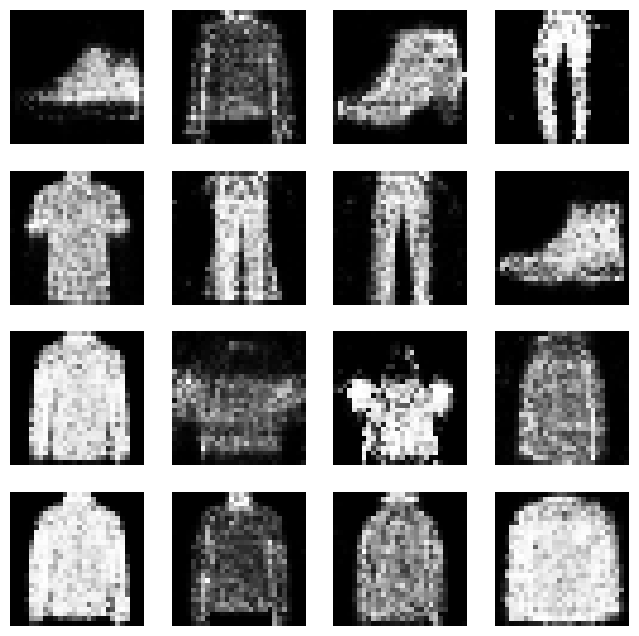

Epoch [21/50] Batch 0/469                         Loss D: 1.3793, Loss G: 0.7878
Epoch [21/50] Batch 100/469                         Loss D: 1.3422, Loss G: 0.8225
Epoch [21/50] Batch 200/469                         Loss D: 1.3245, Loss G: 0.8270
Epoch [21/50] Batch 300/469                         Loss D: 1.3323, Loss G: 0.8482
Epoch [21/50] Batch 400/469                         Loss D: 1.3407, Loss G: 0.8148
Epoch [22/50] Batch 0/469                         Loss D: 1.3608, Loss G: 0.8219
Epoch [22/50] Batch 100/469                         Loss D: 1.3316, Loss G: 0.7795
Epoch [22/50] Batch 200/469                         Loss D: 1.3517, Loss G: 0.7860
Epoch [22/50] Batch 300/469                         Loss D: 1.3604, Loss G: 0.8283
Epoch [22/50] Batch 400/469                         Loss D: 1.3817, Loss G: 0.8036
Epoch [23/50] Batch 0/469                         Loss D: 1.3504, Loss G: 0.7942
Epoch [23/50] Batch 100/469                         Loss D: 1.3438, Loss G: 0.8346
Epoch [23/

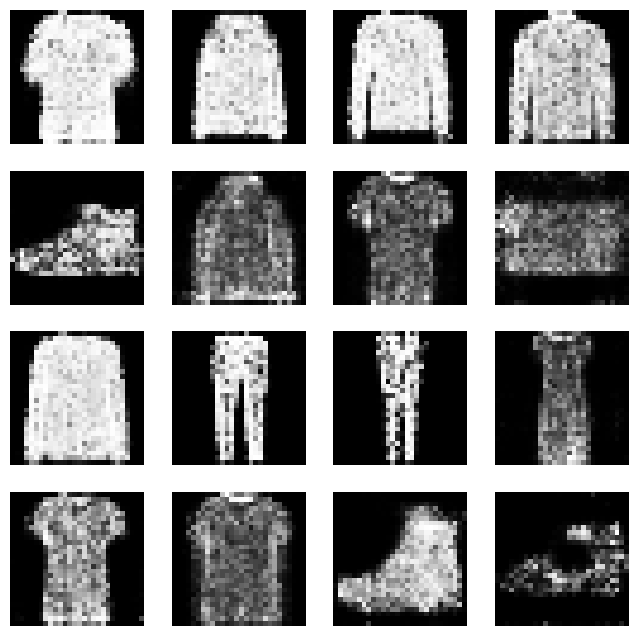

Epoch [31/50] Batch 0/469                         Loss D: 1.3576, Loss G: 0.8095
Epoch [31/50] Batch 100/469                         Loss D: 1.3883, Loss G: 0.8199
Epoch [31/50] Batch 200/469                         Loss D: 1.3332, Loss G: 0.8126
Epoch [31/50] Batch 300/469                         Loss D: 1.3320, Loss G: 0.7692
Epoch [31/50] Batch 400/469                         Loss D: 1.3517, Loss G: 0.8003
Epoch [32/50] Batch 0/469                         Loss D: 1.3135, Loss G: 0.7862
Epoch [32/50] Batch 100/469                         Loss D: 1.3114, Loss G: 0.8014
Epoch [32/50] Batch 200/469                         Loss D: 1.3893, Loss G: 0.7961
Epoch [32/50] Batch 300/469                         Loss D: 1.3021, Loss G: 0.7766
Epoch [32/50] Batch 400/469                         Loss D: 1.3854, Loss G: 0.7610
Epoch [33/50] Batch 0/469                         Loss D: 1.3494, Loss G: 0.8511
Epoch [33/50] Batch 100/469                         Loss D: 1.3391, Loss G: 0.8388
Epoch [33/

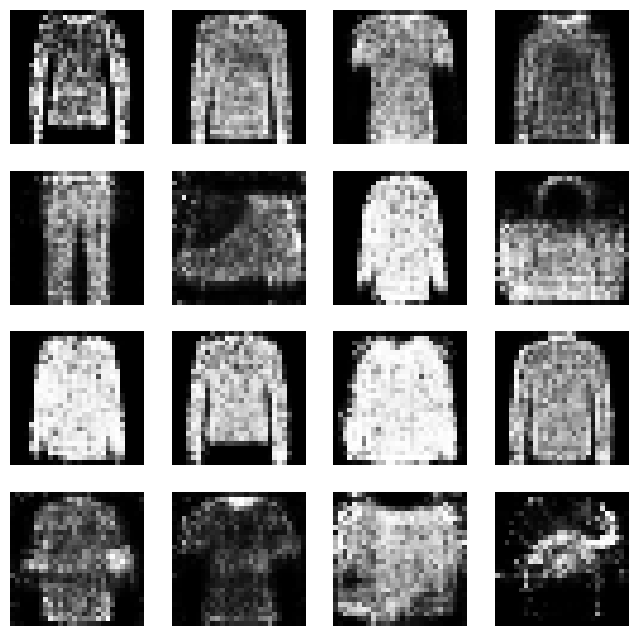

Epoch [41/50] Batch 0/469                         Loss D: 1.3552, Loss G: 0.8024
Epoch [41/50] Batch 100/469                         Loss D: 1.3095, Loss G: 0.7598
Epoch [41/50] Batch 200/469                         Loss D: 1.3532, Loss G: 0.7928
Epoch [41/50] Batch 300/469                         Loss D: 1.3870, Loss G: 0.8079
Epoch [41/50] Batch 400/469                         Loss D: 1.3636, Loss G: 0.8075
Epoch [42/50] Batch 0/469                         Loss D: 1.2971, Loss G: 0.7946
Epoch [42/50] Batch 100/469                         Loss D: 1.3210, Loss G: 0.8142
Epoch [42/50] Batch 200/469                         Loss D: 1.3612, Loss G: 0.8321
Epoch [42/50] Batch 300/469                         Loss D: 1.3399, Loss G: 0.7791
Epoch [42/50] Batch 400/469                         Loss D: 1.3646, Loss G: 0.7908
Epoch [43/50] Batch 0/469                         Loss D: 1.3387, Loss G: 0.8473
Epoch [43/50] Batch 100/469                         Loss D: 1.3675, Loss G: 0.8097
Epoch [43/

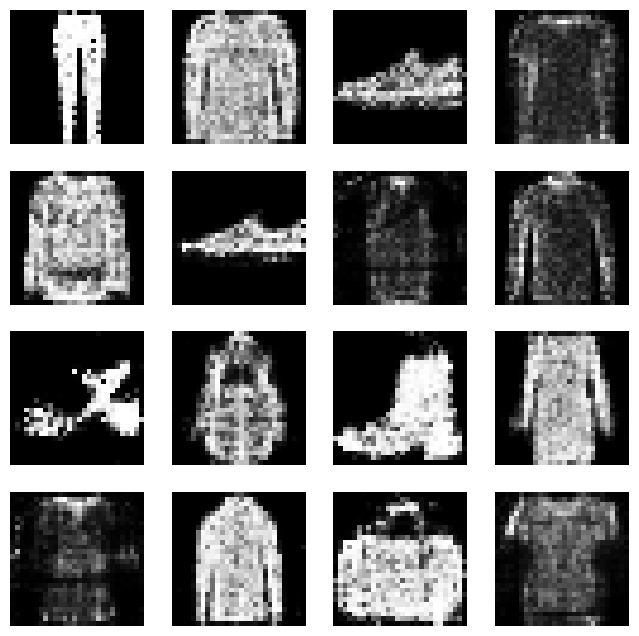

In [18]:
train_gan(discriminator_trainable=True)

In [37]:
train_gan(discriminator_trainable=False)

Training GAN... (discriminator_trainable=False)
Epoch [1/50] Batch 0/469 | Loss D: 0.0000, Loss G: 0.6929
Epoch [1/50] Batch 100/469 | Loss D: 0.0000, Loss G: 0.0104
Epoch [1/50] Batch 200/469 | Loss D: 0.0000, Loss G: 0.0051
Epoch [1/50] Batch 300/469 | Loss D: 0.0000, Loss G: 0.0035
Epoch [1/50] Batch 400/469 | Loss D: 0.0000, Loss G: 0.0024
Epoch [2/50] Batch 0/469 | Loss D: 0.0000, Loss G: 0.0018
Epoch [2/50] Batch 100/469 | Loss D: 0.0000, Loss G: 0.0014
Epoch [2/50] Batch 200/469 | Loss D: 0.0000, Loss G: 0.0017
Epoch [2/50] Batch 300/469 | Loss D: 0.0000, Loss G: 0.0015
Epoch [2/50] Batch 400/469 | Loss D: 0.0000, Loss G: 0.0008
Epoch [3/50] Batch 0/469 | Loss D: 0.0000, Loss G: 0.0009
Epoch [3/50] Batch 100/469 | Loss D: 0.0000, Loss G: 0.0006


KeyboardInterrupt: 

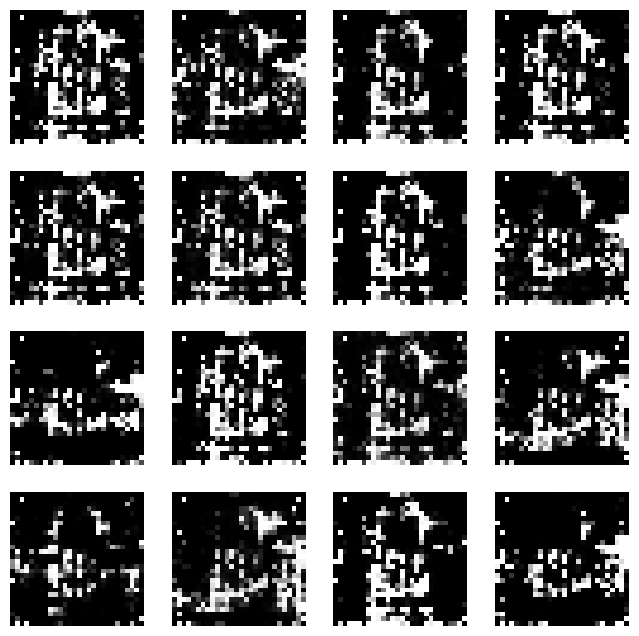

In [38]:
noise = torch.randn(16, LATENT_DIM, device=DEVICE)
generate_and_plot(generator, noise)